### Import dependencies

In [1]:
#%matplotlib widget
%matplotlib inline
import os as os
import warnings
warnings.filterwarnings('ignore')
from tqdm import tqdm
# visualizations and data cleaning
import pandas as pd
import numpy as np
from scipy.signal import butter, lfilter, freqz
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib.animation as animation
from IPython import display
import urllib.request

In [2]:
mpl.rcParams.update({'font.size': 18})
mpl.rcParams.update({'font.size': 20})
mpl.rcParams['font.family'] = 'serif'

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
%cd /content/drive/Shareddrives/2DM/01 User Accounts/Sarkar/FDTD SPP/Final - x pol -compile/IFC/DC_0.533

/content/drive/Shareddrives/2DM/01 User Accounts/Sarkar/FDTD SPP/Final - x pol -compile/IFC/DC_0.533


### Read .txt files

In [13]:
matrix_list = []

path_var = r"/content/drive/Shareddrives/2DM/01 User Accounts/Sarkar/FDTD SPP/Final - x pol -compile/IFC/DC_0.533"

for path, currentDirectory, files in os.walk(path_var):
    for file in files:
        if file.startswith("") and file.endswith(".txt"):
            matrix_list.append(file)

In [14]:
def read_kx_ky_DOS(fname_in):
    f = open(fname_in, encoding="utf-8")

    row_ind = 0
    for line in f:

        if str(line).find("kx 1/nm")!=-1:
            x_start_ind = row_ind + 1
            x_num = int(str(line)[str(line).find("kx 1/nm") + 8 : str(line).find(",")])
        if str(line).find("ky 1/nm")!=-1:
            y_start_ind = row_ind + 1
            y_num = int(str(line)[str(line).find("ky 1/nm") + 8 : str(line).find(",")])

        row_ind += 1

    kx_array = np.loadtxt(fname_in, skiprows=x_start_ind, max_rows=x_num)
    ky_array = np.loadtxt(fname_in, skiprows=y_start_ind, max_rows=y_num)
    DOS_grid = np.loadtxt(fname_in, skiprows= row_ind - x_num - 1)

    return kx_array, ky_array, DOS_grid

In [15]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as colors
from sklearn.preprocessing import normalize
import re

import scipy as sp
from scipy.ndimage.filters import gaussian_filter1d

In [16]:
matrix_list

['IFC_600nm.txt',
 'IFC_800nm.txt',
 'IFC_1000nm.txt',
 'IFC_700nm.txt',
 'IFC_750nm.txt',
 'IFC_550nm.txt',
 'IFC_500nm.txt',
 'IFC_650nm.txt']

In [17]:
regex = re.compile(r'\d+')

In [18]:
data = []
peak_col_list = []
lambda_list = []

x = np.linspace(-1,1,1000)
y = np.linspace(0,1,1000)

for i in range(len(matrix_list)):
  wl = [int(x) for x in regex.findall(matrix_list[i])][0]
  lambda_list.append(wl)
  data.append(read_kx_ky_DOS(matrix_list[i]))
  temp = read_kx_ky_DOS(matrix_list[i])
  Z_data = normalize(temp[2], axis=1, norm='max')
  # Find peak
  peak_col = []
  for i in range(len(x)):
    col = Z_data[i,:].tolist()
    id = col.index(np.max(col))
    peak_col.append(y[id])
  peak_col_list.append(peak_col)

In [19]:
lambda_list

[600, 800, 1000, 700, 750, 550, 500, 650]

In [20]:
peak_col_list[1] = gaussian_filter1d(peak_col_list[1], sigma=20)

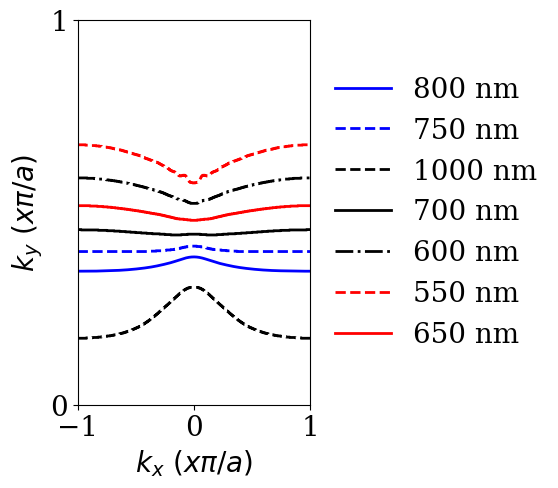

In [21]:
files = [1,4,2,3,0,5,7]
plotstyle = ['b-', 'b--', 'k--', 'k-', 'k-.', 'r--', 'r-']
x = np.linspace(-1,1,1000)


fig,ax = plt.subplots(figsize=(3,5))
temp = -1

for i in files:
  temp += 1
  plot_list = peak_col_list[i]
  plot_list = [i for i in plot_list]
  plt.plot(x, plot_list, plotstyle[temp], lw=2, label='%i nm' % lambda_list[i])

#plt.plot(x, 0.3-x**2, 'k-', lw=1, )
ax.set_xlabel('$k_x$ $(x \pi/a)$')
ax.set_ylabel('$k_y$ $(x \pi/a)$')
plt.xlim(-1,1)
ax.set_xticks([-1,0,1])

ax.set_ylim(0,1)
ax.set_yticks([0,1])

plt.legend(frameon=False,loc='center left', bbox_to_anchor=(1, 0.5))
fig.savefig("IFC.svg", format="svg", dpi=300, bbox_inches=0, transparent=True)

In [22]:
data1 = read_kx_ky_DOS("IFC_800nm.txt")

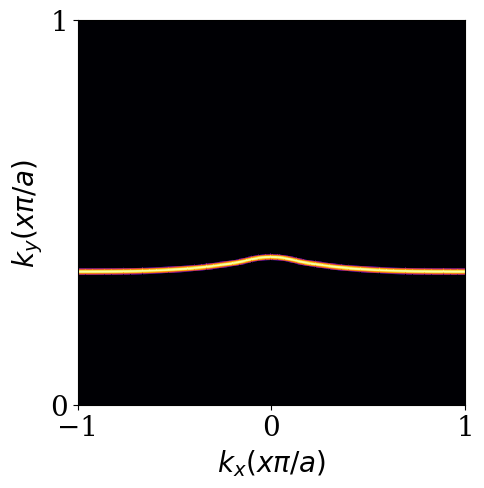

In [23]:
data_target = data1

x = np.linspace(-1,1,1000)
y = np.linspace(0,1,1000)

plot_x, plot_y = np.meshgrid(x, y, indexing='ij')

fig, ax = plt.subplots(figsize=(5,5))

Z = normalize(data_target[2], axis=1, norm='max')

plot_targ = ax.pcolor(plot_x, plot_y, Z, cmap = mpl.cm.inferno, clim=(0.9,1))

ax.set_xlabel('$k_x (x \pi/a)$')
ax.set_ylabel('$k_y (x \pi/a)$')
plt.xlim(-1,1)
ax.set_ylim(0,1)
ax.set_xticks([-1,0,1])
ax.set_yticks([0,1])

#cbar = fig.colorbar(plot_targ, ax=ax)
#cbar.set_ticks([0,0.005])

#fig.savefig("IFC_800nm.png", format="png", dpi=300, bbox_inches='tight', transparent=True)

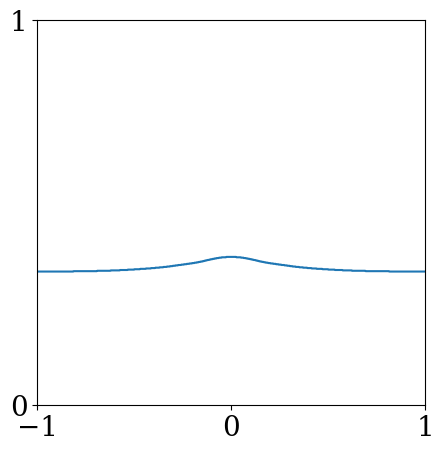

In [24]:
peak_col = []
for i in range(len(x)):
  col = Z[i,:].tolist()
  id = col.index(np.max(col))
  peak_col.append(y[id])

fig, ax = plt.subplots(figsize=(5,5))
plt.plot(x,peak_col)
plt.xlim(-1,1)
ax.set_ylim(0,1)
ax.set_xticks([-1,0,1])
ax.set_yticks([0,1])

Text(0, 0.5, '$k_y (\\mu m^{-1})$')

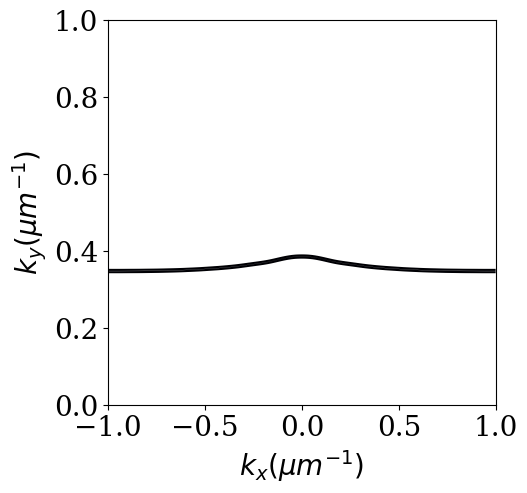

In [25]:
data_target = data1

fig, ax = plt.subplots(figsize=(5,5))

Z = normalize(data_target[2], axis=1, norm='max')

plot_targ = ax.contour(plot_x, plot_y, Z, [0.99], cmap = mpl.cm.inferno)

ax.set_xlabel('$k_x (\mu m^{-1})$')
ax.set_ylabel('$k_y (\mu m^{-1})$')


#cbar = fig.colorbar(plot_targ, ax=ax)
#cbar.set_ticks([0,0.005])

#fig.savefig("IFC_600nm.png", format="png", dpi=300, bbox_inches='tight', transparent=True)